In [22]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
# from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
# from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
# from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [23]:
import importlib
import parse_levels
importlib.reload(parse_levels)
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage, compute_gap_in_percentage_list, convert_to_dict_multiple_runs
from parse_levels import filter_folder_info


In [3]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
# def deduplicate_metrics(search_results):
#     records_length_so_far = {}
#     new_search_results = {}
#     for key, value in search_results.items():
#         if value['record'] not in records_length_so_far:
#             records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#             new_search_results[key] = value
#         else:
#             if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
#                 new_search_results.pop(records_length_so_far[value['record']][1])

#                 records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
#                 new_search_results[key] = value
#     return new_search_results



In [4]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#     ]
# )
# with open('/checkpoint/maui/zhaobc/scientist/code_analysis_with_all_versions_knowledge_o3_mini.json', 'r') as f:
#     o3_results = json.load(f)


In [5]:
# with open('may8.cache', 'w') as f:
#     json.dump(ori_results, f)

In [5]:
with open('/home/zhaobc/scientist/plot/may14.cache', 'r') as f:
    ori_results = json.load(f)

In [6]:
# z_folder_info = filter_folder_info(ori_results, [('levels', 'z')])
unique_levels = set()
for key, value in ori_results.items():
    unique_levels.add(value['levels'][0])
unique_levels

{1, 12, 125, 129, 19, 2, 5, 'z'}

In [8]:
# 1 is psuedo-code
# 2 is text description
# 5 is paper like 
# 9 is adhoc knowledge, we can ignore it for now
# 'z' is zero knowledge

In [7]:
folder_info = ori_results
# o3_results

In [8]:
len(folder_info)

3593

In [9]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    # ('n_initial_hypotheses', 50),
    ('n_iterations', 1),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'ori_aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in ['z', 1, 2, 5, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
        # for model in ['o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat z deepseek-r1 20
flat z o3-mini 60
flat 1 deepseek-r1 31
flat 1 o3-mini 99
flat 2 deepseek-r1 20
flat 2 o3-mini 60
flat 5 deepseek-r1 60
flat 5 o3-mini 60
flat 12 deepseek-r1 71
flat 12 o3-mini 64
flat 125 deepseek-r1 75
flat 125 o3-mini 55
tree z deepseek-r1 20
tree z o3-mini 60
tree 1 deepseek-r1 18
tree 1 o3-mini 106
tree 2 deepseek-r1 20
tree 2 o3-mini 60
tree 5 deepseek-r1 60
tree 5 o3-mini 60
tree 12 deepseek-r1 58
tree 12 o3-mini 51
tree 125 deepseek-r1 75
tree 125 o3-mini 74
forest z deepseek-r1 20
forest z o3-mini 60
forest 1 deepseek-r1 18
forest 1 o3-mini 106
forest 2 deepseek-r1 20
forest 2 o3-mini 60
forest 5 deepseek-r1 60
forest 5 o3-mini 60
forest 12 deepseek-r1 55
forest 12 o3-mini 64
forest 125 deepseek-r1 90
forest 125 o3-mini 70
ori_aide z deepseek-r1 20
ori_aide z o3-mini 60
ori_aide 1 deepseek-r1 15
ori_aide 1 o3-mini 106
ori_aide 2 deepseek-r1 20
ori_aide 2 o3-mini 60
ori_aide 5 deepseek-r1 57
ori_aide 5 o3-mini 57
ori_aide 12 deepseek-r1 55
ori_aide 12 o3-m

In [26]:
from tqdm import tqdm

figure_data = {}
for search_algo in search_algo_params.keys():
    for level in ['z', 1, 2, 5, 12, 125]:
        # for model in ['o3-mini']:
        for model in ['deepseek-r1', 'o3-mini']:
            # plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
            try:
                plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
                figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
            except FileNotFoundError as e:
                print(f"FileNotFoundError for {search_algo}, level {level}, model {model}: {e}")


In [24]:
# let's run for o3-mini and 125 hints for now
figure_data = {}
for search_algo in search_algo_params.keys():
    for level in [125]:
        for model in ['o3-mini']:
            try:
                plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
                figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict_multiple_runs(plot_info[search_algo][level][model], keep_name=True)
            except (FileNotFoundError, ValueError) as e:
                print(f"FileNotFoundError for {search_algo}, level {level}, model {model}: {e}")


In [28]:
len(figure_data)
len(plot_info)
figure_data.keys()
# plot_info.keys()

dict_keys(['flat_125_o3-mini', 'tree_125_o3-mini', 'forest_125_o3-mini', 'ori_aide_125_o3-mini', 'multi_aide_125_o3-mini'])

In [12]:
human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442,
    20: 188680,
    21: 184262
}


In [19]:
plot_info

{'flat': {'z': {'deepseek-r1': {'record_8_20250504_161022_2201299-2200954-7': {'record': 8,
     'levels': ['z'],
     'ideator': 'dummy',
     'knowledge_coder': False,
     'runner': 'bon',
     'model': 'deepseek-r1',
     'n_initial_hypotheses': 20,
     'n_hypotheses': 3,
     'debug_prob': None,
     'n_iterations': 1},
    'record_3_20250504_161022_2201294-2200954-2': {'record': 3,
     'levels': ['z'],
     'ideator': 'dummy',
     'knowledge_coder': False,
     'runner': 'bon',
     'model': 'deepseek-r1',
     'n_initial_hypotheses': 20,
     'n_hypotheses': 3,
     'debug_prob': None,
     'n_iterations': 1},
    'record_10_20250504_161022_2200954-2200954-9': {'record': 10,
     'levels': ['z'],
     'ideator': 'dummy',
     'knowledge_coder': False,
     'runner': 'bon',
     'model': 'deepseek-r1',
     'n_initial_hypotheses': 20,
     'n_hypotheses': 3,
     'debug_prob': None,
     'n_iterations': 1},
    'record_11_20250504_141040_2200385-2200330-0': {'record': 11,
    

In [26]:
figure_data


{'flat_125_o3-mini': defaultdict(list,
             {17: [('record_17_20250430_101618_2166908-2157878-6', 220374.0),
               ('record_17_20250424_065957_2089273-2088450-6', 217916.0),
               ('record_17_20250502_121335_2186304-2185770-6', 219445.0)],
              4: [('record_4_20250424_065837_2088655-2088441-3', 1022168.0),
               ('record_4_20250502_004531_2182789-2182654-3', 932033.0),
               ('record_4_20250430_101650_2174440-2157899-3', 1301740.0)],
              7: [('record_7_20250430_101650_2174443-2157899-6', 773072.0),
               ('record_7_20250424_065837_2088791-2088441-6', 690188.0),
               ('record_7_20250502_004531_2182792-2182654-6', 773072.0)],
              12: [('record_12_20250502_121335_2186298-2185770-1', 314803.0),
               ('record_12_20250430_101618_2165967-2157878-1', 317839.0),
               ('record_12_20250424_065957_2089103-2088450-1', 289589.0)],
              5: [('record_5_20250502_004531_2182790-218265

In [ ]:
len(figure_data)

5

In [29]:
figure_data_percent = {}
for key in figure_data.keys():
    print(key)
    figure_data_percent[key] = compute_gap_in_percentage_list(figure_data[key], human_train_time_dict, keep_name=True)
    figure_data_percent[key] = {str(k): v for k, v in figure_data_percent[key].items()}
    try:
        del figure_data_percent[key]['6']
    except:
        pass

flat_125_o3-mini
tree_125_o3-mini
forest_125_o3-mini
ori_aide_125_o3-mini
multi_aide_125_o3-mini


In [30]:
figure_data_percent

{'flat_125_o3-mini': {'17': array([0.        , 0.28802437, 0.10885868]),
  '4': array([0.79376058, 1.04967179, 0.        ]),
  '7': array([0.        , 0.74759847, 0.        ]),
  '12': array([0.10829707, 0.        , 1.00770493]),
  '5': array([0.95944759, 0.        , 0.98258844]),
  '13': array([0.        , 0.        , 0.11151036]),
  '18': array([0.16776899, 0.25576706, 0.        ]),
  '15': array([0.26966557, 0.        , 0.20654734]),
  '16': array([0.        , 0.25506073, 0.        ]),
  '1': array([0., 0.]),
  '10': array([0.98706278, 0.        , 1.04188497]),
  '3': array([0., 0.]),
  '11': array([0.        , 0.07543989, 0.        ]),
  '14': array([0.25274934, 0.        , 0.26390469]),
  '2': array([0., 0.]),
  '8': array([0., 0., 0.]),
  '19': array([0.52657499, 0.        ]),
  '9': array([1.48972904, 0.81667313, 0.        ])},
 'tree_125_o3-mini': {'19': array([0.        , 0.05974726, 0.        ]),
  '12': array([0.98740815, 1.05300706, 0.        , 0.        ]),
  '11': array([

In [16]:
figure_data_percent.keys()


dict_keys(['flat_125_o3-mini', 'forest_125_o3-mini', 'ori_aide_125_o3-mini', 'multi_aide_125_o3-mini'])

In [39]:
# Get top 3 values for each experiment, padding if needed
def get_top_3_values(arr, config=None, exp_name=None):
    if len(arr) == 0:
        return np.array([0, 0, 0])
    # Filter out values > 3 or < 0
    valid_arr = []
    for x in arr:
        if not (0 <= x <= 3):
            print(f"Warning: Value {x} from {config} {exp_name} outside valid range [0,3], replacing with 0")
            valid_arr.append(0)
        else:
            valid_arr.append(x)
    sorted_arr = np.sort(valid_arr)[::-1] # Sort descending
    if len(arr) >= 3:
        return sorted_arr[:3]
    else:
        # Pad with repeats of max value to get 3 numbers
        padding = 3 - len(arr)
        if not ('r1' in config):
            # Only log warning once per config
            if exp_name == list(figure_data_percent[config].keys())[0]:
                print(f"Warning: Config {config} has experiments with fewer than 3 values, padding with {padding} repeated values")
        return np.concatenate([sorted_arr, np.repeat(sorted_arr[-1], padding)])

# Process each config
results_by_config = {}
for config, experiments in figure_data_percent.items():
    print(f"Processing config: {config}")
    print(f"Experiments: {list(experiments.keys())}")
    # Get top 3 values for each experiment
    top3_by_experiment = {}
    if len(experiments) == 0:
        print(f'Warning: {config} has no experiments')
    for exp_name, values in experiments.items():
        print(f"Experiment Name: {exp_name}, Values: {values}")
        top3 = get_top_3_values(values, config, exp_name)
        top3_by_experiment[exp_name] = top3
    
    # Average across experiments for each of the 3 positions
    all_exp_values = np.array(list(top3_by_experiment.values()))
    mean_values = np.mean(all_exp_values, axis=0) # Shape (3,)
    
    # Calculate standard error of the mean (SEM) instead of std
    n = len(all_exp_values) if len(all_exp_values) > 0 else 1
    sem_value = np.std(mean_values) / np.sqrt(n)
    print("All experiment values (top 3 for each experiment):")
    print(all_exp_values)
    results_by_config[config] = {
        'means': np.mean(mean_values) if len(all_exp_values) > 0 else 0,
        'std': sem_value if len(all_exp_values) > 0 else 0,  # Using 'std' key for compatibility but storing SEM
        'all_exp_values': all_exp_values,
    }



Processing config: flat_125_o3-mini
Experiments: ['17', '4', '7', '12', '5', '13', '18', '15', '16', '1', '10', '3', '11', '14', '2', '8', '19', '9']
Experiment Name: 17, Values: [0.         0.28802437 0.10885868]
Experiment Name: 4, Values: [0.79376058 1.04967179 0.        ]
Experiment Name: 7, Values: [0.         0.74759847 0.        ]
Experiment Name: 12, Values: [0.10829707 0.         1.00770493]
Experiment Name: 5, Values: [0.95944759 0.         0.98258844]
Experiment Name: 13, Values: [0.         0.         0.11151036]
Experiment Name: 18, Values: [0.16776899 0.25576706 0.        ]
Experiment Name: 15, Values: [0.26966557 0.         0.20654734]
Experiment Name: 16, Values: [0.         0.25506073 0.        ]
Experiment Name: 1, Values: [0. 0.]
Experiment Name: 10, Values: [0.98706278 0.         1.04188497]
Experiment Name: 3, Values: [0. 0.]
Experiment Name: 11, Values: [0.         0.07543989 0.        ]
Experiment Name: 14, Values: [0.25274934 0.         0.26390469]
Experiment Na

In [40]:
results_by_config['flat_125_o3-mini']

{'means': 0.2364127923638016,
 'std': 0.044738941178733595,
 'all_exp_values': array([[0.28802437, 0.10885868, 0.        ],
        [1.04967179, 0.79376058, 0.        ],
        [0.74759847, 0.        , 0.        ],
        [1.00770493, 0.10829707, 0.        ],
        [0.98258844, 0.95944759, 0.        ],
        [0.11151036, 0.        , 0.        ],
        [0.25576706, 0.16776899, 0.        ],
        [0.26966557, 0.20654734, 0.        ],
        [0.25506073, 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [1.04188497, 0.98706278, 0.        ],
        [0.        , 0.        , 0.        ],
        [0.07543989, 0.        , 0.        ],
        [0.26390469, 0.25274934, 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.52657499, 0.        , 0.        ],
        [1.48972904, 0.81667313, 0.        ]])}

In [42]:
from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

In [43]:
results_by_config.keys()


dict_keys(['flat_125_o3-mini', 'tree_125_o3-mini', 'forest_125_o3-mini', 'ori_aide_125_o3-mini', 'multi_aide_125_o3-mini'])

In [44]:
# algorithms = ['DQN (Nature)', 'DQN (Adam)', 'C51', 'REM', 'Rainbow',
#               'IQN', 'M-IQN', 'DreamerV2']
searches = ['flat_125_o3-mini', 'tree_125_o3-mini', 'forest_125_o3-mini', 'ori_aide_125_o3-mini', 'multi_aide_125_o3-mini']
# Load ALE scores as a dictionary mapping algorithms to their human normalize
# score matrices, each of which is of size `(num_runs x num_games)`.
# atari_200m_normalized_score_dict = ...
searches_fsr_all_exp_values_dict = {key: value['all_exp_values'] for key, value in results_by_config.items()}
aggregate_func = lambda x: np.array([
  metrics.aggregate_median(x),
  metrics.aggregate_iqm(x),
  metrics.aggregate_mean(x),
  metrics.aggregate_optimality_gap(x)])

In [45]:
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(
  searches_fsr_all_exp_values_dict, aggregate_func, reps=50000)


INFO:absl:Calculating estimates for flat_125_o3-mini ...
INFO:absl:Calculating estimates for tree_125_o3-mini ...
INFO:absl:Calculating estimates for forest_125_o3-mini ...
INFO:absl:Calculating estimates for ori_aide_125_o3-mini ...
INFO:absl:Calculating estimates for multi_aide_125_o3-mini ...


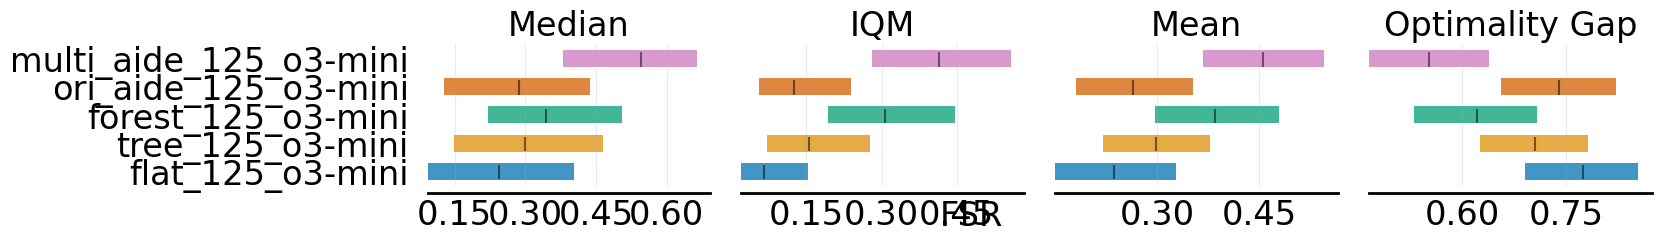

In [ ]:
fig, axes = plot_utils.plot_interval_estimates(
  aggregate_scores, aggregate_score_cis,
  metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
  algorithms=searches, xlabel='FSR')

Text(0.5, 0, 'FSR')

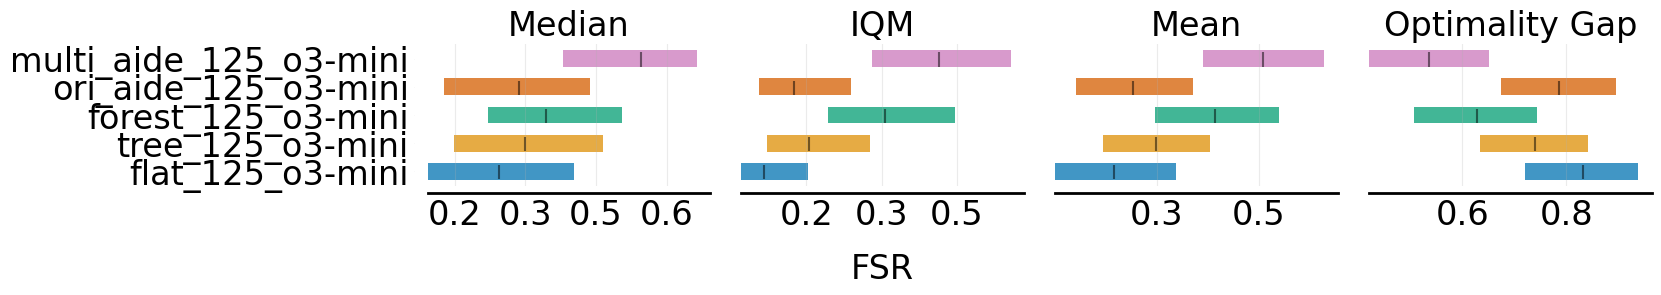

In [57]:
from matplotlib.ticker import FuncFormatter

# Define a formatter to reduce the number of decimal digits
formatter = FuncFormatter(lambda x, _: f'{x:.1f}')

fig, axes = plot_utils.plot_interval_estimates(
    aggregate_scores, aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=searches, xlabel='',)

# Apply the formatter to all x-axes
for ax in axes:
    ax.xaxis.set_major_formatter(formatter)

# Adjust the position and font size of the xlabel for the IQM plot to avoid overlap
axes[1].set_xlabel('FSR', labelpad=15, fontsize=24)  # Increase labelpad and fontsize

In [41]:
top3_by_experiment.keys()

dict_keys(['8', '14', '18', '13', '4', '19', '11', '2', '7', '17', '10', '3', '12', '1', '15', '5', '16', '9'])

In [32]:
figure_data_percent['ori_aide_1_deepseek-r1']

{'9': array([17.7997604]),
 '14': array([0.]),
 '8': array([4.2248682]),
 '16': array([0.]),
 '13': array([0.]),
 '11': array([0.]),
 '4': array([0.68158098]),
 '18': array([7.12889176]),
 '10': array([0.]),
 '15': array([0.48539802]),
 '7': array([0.]),
 '5': array([0.99460902]),
 '12': array([0.]),
 '17': array([0.25615186])}

In [33]:
import matplotlib as mpl

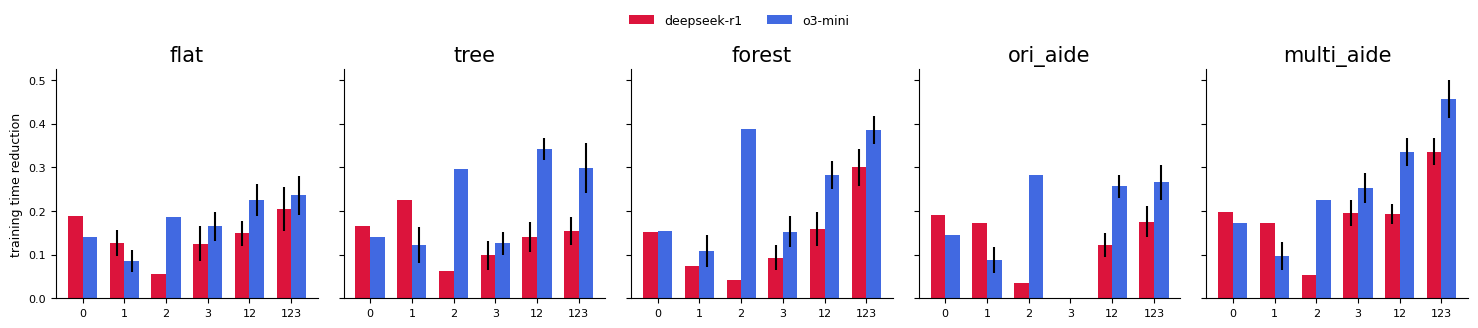

In [ ]:
colors = ['crimson', 'royalblue']
colors = ['crimson', 'royalblue', 'gold', 'forestgreen', 'purple']
# colors = [plt.cm.get_cmap('plasma')(level) for level in [0.3, 0.9]]
# x_labels = ['z', 1, 2, 5, 12, 125]
x_labels = [0, 1, 2, 3, 12, 123]
x_values = np.arange(len(x_labels))
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
w = 0.35

for idx, search_algo in enumerate(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']):
    for i, model in enumerate(['deepseek-r1', 'o3-mini']):
        y = []
        err = []
        for level in ['z', 1, 2, 5, 12, 125]:
            key = f'{search_algo}_{level}_{model}'
            if key in results_by_config:
                y.append(results_by_config[key]['means'])
                err.append(results_by_config[key]['std'])
            else:
                y.append(0)
                err.append(0)
        axes[idx].bar(x_values - w/2 + i * w, y, width=w, color=colors[i], label=model if idx == 0 else "", yerr=err)
    
    axes[idx].set_title(search_algo, fontsize=15)
    axes[idx].set_xticks(x_values)
    axes[idx].set_xticklabels(x_labels, fontsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    if idx == 0:
        axes[idx].set_ylabel('training time reduction', fontsize=9)

# shared legend above all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 1.05])
plt.show()

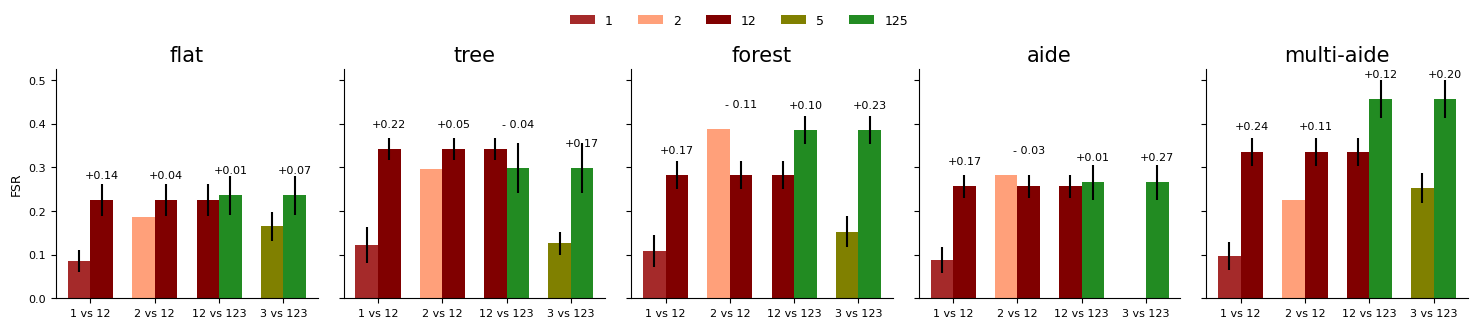

In [85]:
# colors = ['magma', 'plasma']
# colors = ['crimson', 'royalblue', 'gold', 'forestgreen', 'purple']
earthy_colors = ['brown', 'lightsalmon', 'olive', 'maroon', 'forestgreen']
color_mapping = {1: 'brown', 2: 'lightsalmon', 5: 'olive', 12: 'maroon', 125: 'forestgreen'}
x_labels = ['1 vs 12', '2 vs 12', '12 vs 123', '3 vs 123']
x_values = np.arange(len(x_labels))
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
w = 0.35

for idx, search_algo in enumerate(['flat', 'tree', 'forest', 'ori_aide', 'multi_aide']):
    z = []
    for i, level in enumerate([1, 12]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[0:1] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- '
            axes[idx].text(x_values[0] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=8)

    z = []
    for i, level in enumerate([2, 12]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[1:2] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- '
            axes[idx].text(x_values[1] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=8)

    z = []
    for i, level in enumerate([12, 125]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[2:3] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- '
            axes[idx].text(x_values[2] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=8)

    z = []
    for i, level in enumerate([5, 125]):
        y = []
        err = []
        key = f'{search_algo}_{level}_o3-mini'
        if key in results_by_config:
            y.append(results_by_config[key]['means'])
            z.append(results_by_config[key]['means'])
            err.append(results_by_config[key]['std'])
        else:
            y.append(0)
            z.append(0)
            err.append(0)
        axes[idx].bar(x_values[3:4] - w/2 + i * w, y, width=w, color=color_mapping[level], label=level if idx == 0 else "", yerr=err)
        if len(z) == 2:
            diff = z[1] - z[0]
            sign = '+' if diff > 0 else '- ' 
            axes[idx].text(x_values[3] - w/2 + i * w, max(z) + 0.05, f'{sign}{abs(diff):.2f}', ha='center', fontsize=8)
    
    if search_algo == 'ori_aide':
        search_algo = 'aide'
    elif search_algo == 'multi_aide':
        search_algo = 'multi-aide'
    axes[idx].set_title(search_algo, fontsize=15)
    axes[idx].set_xticks(x_values)
    axes[idx].set_xticklabels(x_labels, fontsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    if idx == 0:
        axes[idx].set_ylabel('FSR', fontsize=9)

# shared legend above all plots
handles, labels = axes[0].get_legend_handles_labels()
handles = [h for i, h in enumerate(handles) if i not in [1, 4, 5]]
labels = [l for i, l in enumerate(labels) if i not in [1, 4, 5]]
fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.12))

fig.tight_layout(rect=[0, 0, 1, 1.05])
plt.show()

In [56]:
from parse_levels import process_metrics_raw_path, list_of_base_paths


In [57]:
r1_codes_dist = pd.read_csv('/checkpoint/maui/zhaobc/scientist/may11_r1_code.csv')
o3_codes_dist = pd.read_csv('/checkpoint/maui/zhaobc/scientist/may11_o3_code.csv')

In [23]:
o3_codes_dist = pd.concat([r1_codes_dist, o3_codes_dist])

In [24]:
o3_codes_dist['run_id'].unique().shape

(2310,)

In [25]:
norm_o3_codes_dist = o3_codes_dist.copy()
norm_o3_codes_dist['norm_cos_start'] = norm_o3_codes_dist['cos_start'] / norm_o3_codes_dist['human_cos'] 
norm_o3_codes_dist['norm_cos_end'] = norm_o3_codes_dist['cos_end'] / norm_o3_codes_dist['human_cos']
norm_o3_codes_dist['norm_l2_start'] = norm_o3_codes_dist['l2_start'] / norm_o3_codes_dist['human_l2']
norm_o3_codes_dist['norm_l2_end'] = norm_o3_codes_dist['l2_end'] / norm_o3_codes_dist['human_l2']

In [26]:
# norm_o3_codes_dist.head()

In [27]:
min_train_time_list = []
for idx, row in tqdm(norm_o3_codes_dist.iterrows(), total=len(norm_o3_codes_dist)):
    for base_path in list_of_base_paths:
        run_folder = os.path.join(base_path, row['run_id'])
        if os.path.exists(run_folder):
            break
    metrics = process_metrics_raw_path(run_folder, row['record'])
    min_train_time = metrics['train_time'].min()
    min_train_time_list.append(min_train_time)

  0%|          | 0/2310 [00:00<?, ?it/s]

100%|██████████| 2310/2310 [00:57<00:00, 40.04it/s]


In [28]:
norm_o3_codes_dist['min_train_time'] = min_train_time_list
# norm_o3_codes_dist.head()

In [ ]:
gap_list = []
model_gap_list = []
for idx, row in tqdm(norm_o3_codes_dist.iterrows(), total=len(norm_o3_codes_dist)):
    record_num = row['record']
    human_time = human_train_time_dict[record_num]
    gap = human_time - human_train_time_dict[record_num+1]
    # model_gap = row['min_train_time'] - human_train_time_dict[record_num+1]
    model_gap = human_time - row['min_train_time']
    gap_list.append(gap)
    model_gap_list.append(model_gap)
norm_o3_codes_dist['gap'] = gap_list
norm_o3_codes_dist['model_gap'] = model_gap_list
# norm_o3_codes_dist.head()



100%|██████████| 2310/2310 [00:00<00:00, 42553.15it/s]


In [30]:
norm_o3_codes_dist['reproduced'] = norm_o3_codes_dist['model_gap'] / norm_o3_codes_dist['gap']
norm_o3_codes_dist.head()


# why so many 1?



,method,model,record,levels,run_id,cos_start,cos_end,l2_start,l2_end,human_cos,human_l2,norm_cos_start,norm_cos_end,norm_l2_start,norm_l2_end,min_train_time,gap,model_gap,reproduced
0,tree,deepseek-r1,12,z,record_12_20250504_141041_2200393-2200331-1,-1.192093e-07,0.006341,0.0,17.101551,0.006341,17.101551,-0.000019,1.0,0.0,1.0,312612.0,28034,5227.0,0.186452
1,tree,deepseek-r1,8,z,record_8_20250504_161022_2201339-2200955-7,1.192093e-07,0.011043,0.0,22.534748,0.011043,22.534748,0.000011,1.0,0.0,1.0,662205.0,156674,0.0,0.000000
2,tree,deepseek-r1,19,z,record_19_20250504_181030_2202128-2201681-0,-1.192093e-07,0.039306,0.0,43.281780,0.039306,43.281780,-0.000003,1.0,0.0,1.0,198981.0,10762,461.0,0.042836
3,tree,deepseek-r1,9,z,record_9_20250504_161022_2201340-2200955-8,1.192093e-07,0.007622,0.0,18.767290,0.007622,18.767290,0.000016,1.0,0.0,1.0,505531.0,28381,0.0,0.000000
4,tree,deepseek-r1,10,z,record_10_20250504_161022_2200955-2200955-9,0.000000e+00,0.008124,0.0,19.370594,0.008124,19.370594,0.000000,1.0,0.0,1.0,477150.0,34165,0.0,0.000000


In [31]:
norm_o3_codes_dist.loc[norm_o3_codes_dist['reproduced'] > 1.5, 'reproduced'] = 0
norm_o3_codes_dist.loc[norm_o3_codes_dist['reproduced'] < 0, 'reproduced'] = 0

In [32]:
norm_o3_codes_dist.loc[norm_o3_codes_dist['norm_l2_end'] > 4, 'norm_l2_end'] = 1.0
norm_o3_codes_dist.loc[norm_o3_codes_dist['norm_l2_end'] < 0.1, 'norm_l2_end'] = 1.0

In [33]:
from matplotlib.legend_handler import HandlerTuple

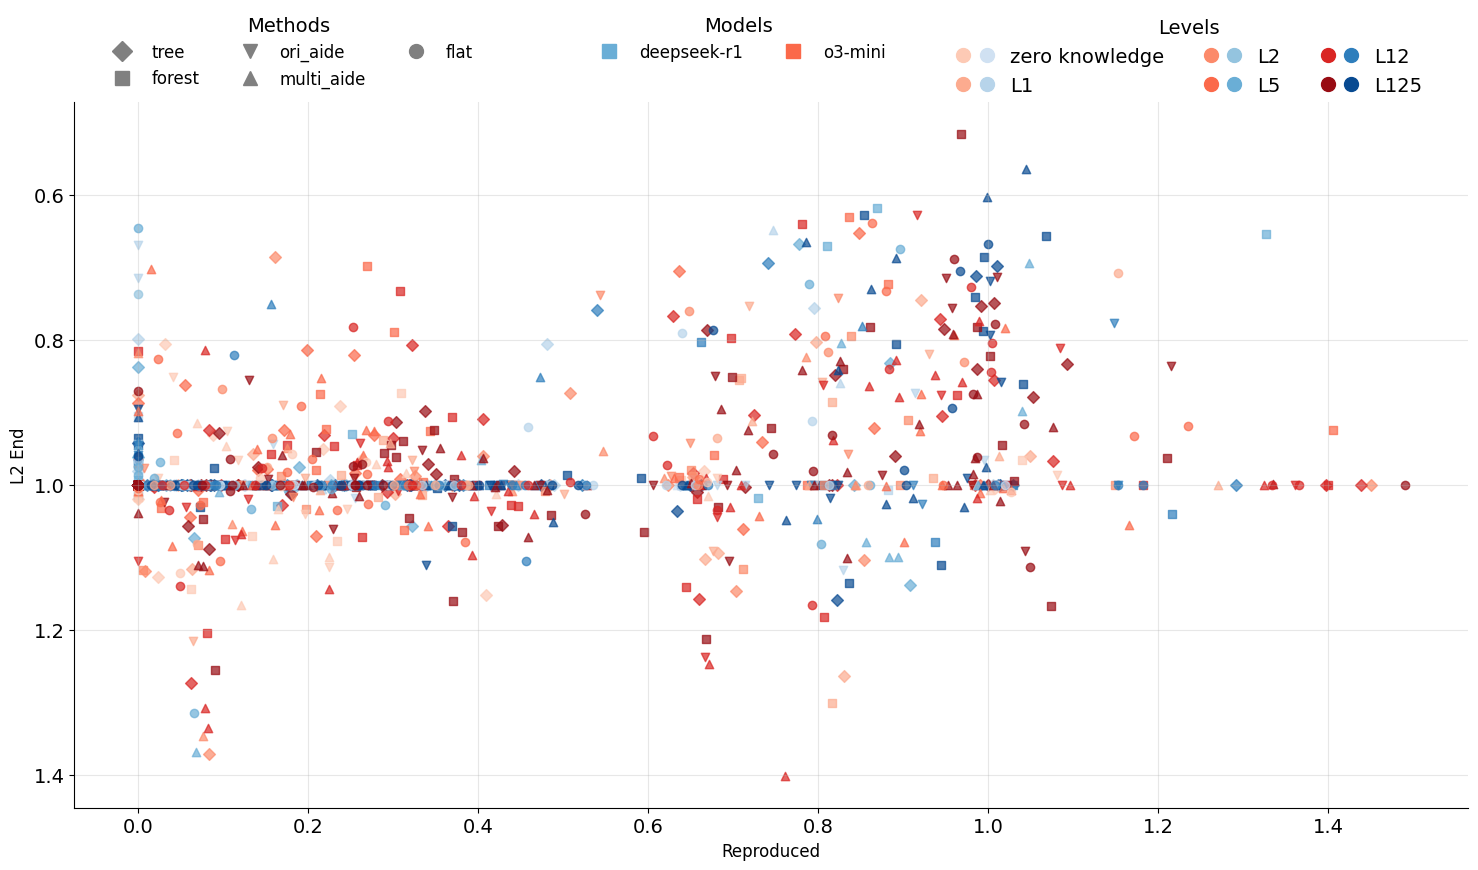

In [34]:
# Get unique methods and models
methods = norm_o3_codes_dist['method'].unique()
models = norm_o3_codes_dist['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colormaps for models
model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}

# Define level darkness scale (0 to 1)
level_darkness = {'z': 0.2, '1': 0.3, '2': 0.4, '5': 0.5, '12': 0.7, '125': 0.9}

fig, ax = plt.subplots(figsize=(15, 8))

# Plot points
for method in methods:
    for model in models:
        for level in ['z', '1', '2', '5', '12', '125']:
            mask = (norm_o3_codes_dist['method'] == method) & \
                   (norm_o3_codes_dist['model'] == model) & \
                   (norm_o3_codes_dist['levels'] == level)
            
            if mask.any():
                cmap = model_cmaps[model]
                color = cmap(level_darkness[level])
                ax.scatter(norm_o3_codes_dist[mask]['reproduced'], 
                         norm_o3_codes_dist[mask]['norm_l2_end'],
                         marker=markers[method],
                         c=[color],
                         alpha=0.7)

ax.set_xlabel('Reproduced', fontsize=12)
ax.set_ylabel('L2 End', fontsize=12)
# ax.set_title('L2 End vs Reproduced by Method, Model and Level', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, alpha=0.3)
ax.invert_yaxis()

# Create legend for methods
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method, markersize=10, linestyle='None')
                 for method in methods]

# Create legend for models and levels 
model_patches = []
for model in models:
    cmap = model_cmaps[model]
    model_patches.append(
        plt.Line2D([0], [0], marker='s', color=cmap(0.5),
                   label=model, markersize=10, linestyle='None')
    )

level_patches = []
level_labels = []
for level in ['z', '1', '2', '5', '12', '125']:
    label = f'L{level}' if level != 'z' else 'zero knowledge'
    color1 = model_cmaps['o3-mini'](level_darkness[level])
    color2 = model_cmaps['deepseek-r1'](level_darkness[level])

    marker_1 = plt.Line2D([0], [0], marker='o', color=color1, markerfacecolor=color1, markersize=10, linestyle='None')
    marker_2 = plt.Line2D([0], [0], marker='o', color=color2, markerfacecolor=color2, markersize=10, linestyle='None')
    level_patches.append((marker_1, marker_2))
    level_labels.append(label)
    # level_patches.append(
    #     plt.Line2D([0], [0], marker='o', color=color,
    #                 label=label, markersize=10, linestyle='None')
    # )

# Place legends at top of figure
fig.legend(handles=method_patches, title='Methods',
           bbox_to_anchor=(0.2, 1.10), loc='upper center',
           ncol=len(method_patches)//2+1, frameon=False, fontsize=12)

fig.legend(handles=model_patches, title='Models',
           bbox_to_anchor=(0.5, 1.10), loc='upper center',
           ncol=len(model_patches), frameon=False, fontsize=12)

# fig.legend(handles=level_patches, title='Levels',
#            bbox_to_anchor=(0.8, 1.05), loc='upper center',
#            ncol=len(level_patches)//2, frameon=False, fontsize=12)
fig.legend(level_patches, level_labels, title='Levels',
           handler_map={tuple: HandlerTuple(ndivide=None)},
           loc='upper center', bbox_to_anchor=(0.8, 1.10),
           ncol=len(level_patches)//2, frameon=False)

plt.tight_layout()
plt.show()

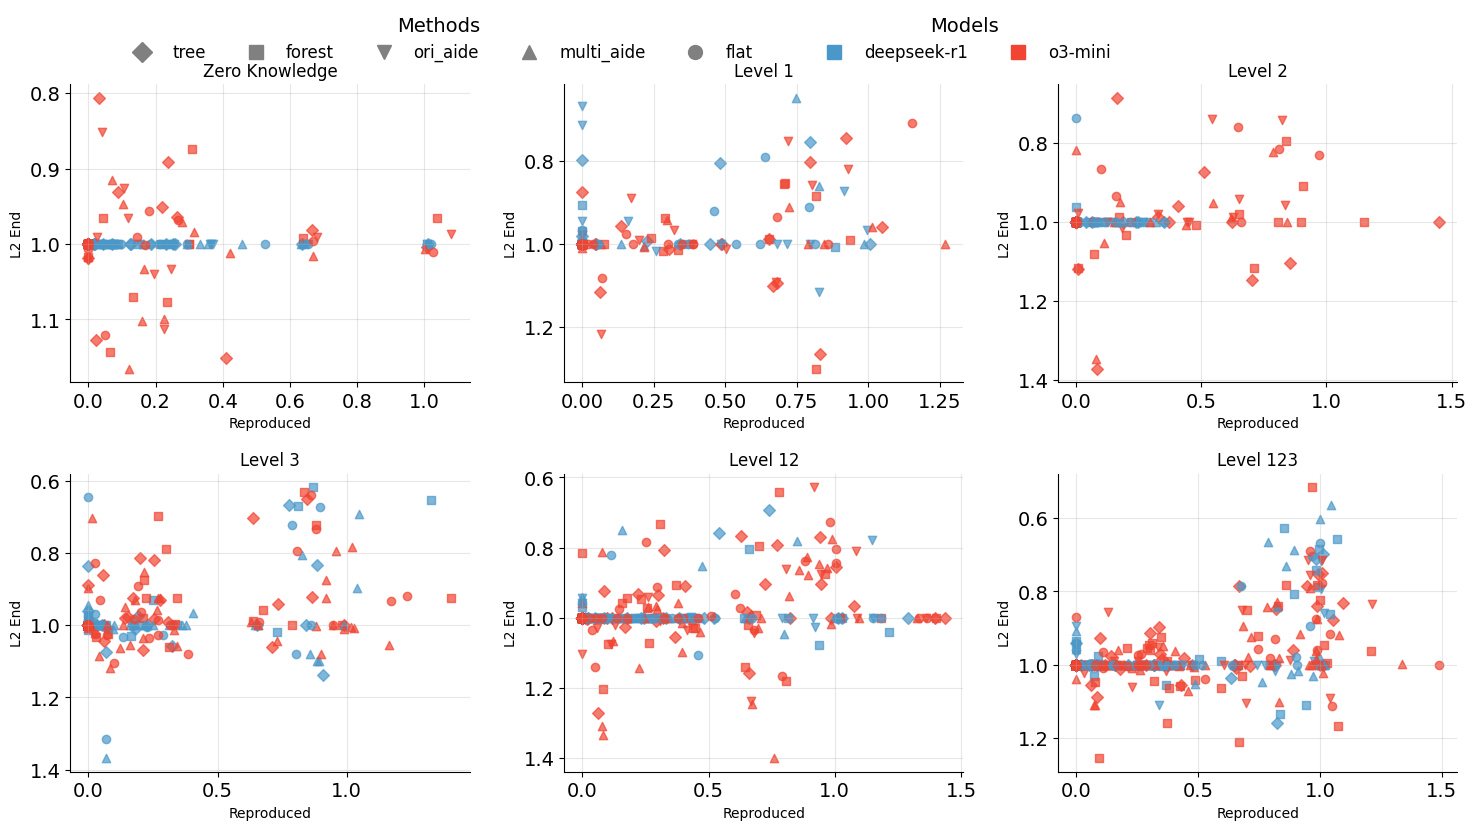

In [68]:
# Get unique methods and models
methods = norm_o3_codes_dist['method'].unique()
models = norm_o3_codes_dist['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colormaps for models
model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}

# Create 3x2 subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

# Plot each level in a separate subplot
for idx, level in enumerate(['z', '1', '2', '5', '12', '125']):
    ax = axs[idx]
    
    # Plot points for this level
    for method in methods:
        for model in models:
            mask = (norm_o3_codes_dist['method'] == method) & \
                   (norm_o3_codes_dist['model'] == model) & \
                   (norm_o3_codes_dist['levels'] == level)
            
            if mask.any():
                cmap = model_cmaps[model]
                color = cmap(0.6)  # Use consistent darkness for clarity
                ax.scatter(norm_o3_codes_dist[mask]['reproduced'], 
                         norm_o3_codes_dist[mask]['norm_l2_end'],
                         marker=markers[method],
                         c=[color],
                         alpha=0.7)

    # Customize each subplot
    level_label_mapping = {
        'z': 'Zero Knowledge',
        '1': 'Level 1',
        '2': 'Level 2',
        '5': 'Level 3',
        '12': 'Level 12',
        '125': 'Level 123'
    }
    level_label = level_label_mapping[level]
    ax.set_title(level_label, fontsize=12)
    ax.set_xlabel('Reproduced', fontsize=10)
    ax.set_ylabel('L2 End', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()

# Create legends
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method, markersize=10, linestyle='None')
                 for method in methods]

model_patches = [plt.Line2D([0], [0], marker='s', color=model_cmaps[model](0.6),
                          label=model, markersize=10, linestyle='None')
                for model in models]

# Add legends to figure
fig.legend(handles=method_patches, title='Methods',
          bbox_to_anchor=(0.30, 1.05), loc='upper center',
          frameon=False, fontsize=12, ncol=len(method_patches))

fig.legend(handles=model_patches, title='Models',
          bbox_to_anchor=(0.65, 1.05), loc='upper center',
          frameon=False, fontsize=12, ncol=len(model_patches))

plt.tight_layout()
plt.show()

In [35]:
judge_file = '/checkpoint/ram/xianl/projects/nanogpt/scientist/r1_scoring_tree_best_v2.jsonl'
judge_data = []
with open(judge_file, 'r') as f:
    for line in f:
        judge_data.append(json.loads(line))

judge_data[0]

{'method': 'tree',
 'level': '12',
 'record': 'record_14_20250502_121340_2186463-2185781-3',
 'human_metrics': {'job_status': 'COMPLETED',
  'metrics': {'n_steps': 1530, 'val_loss': 3.2739, 'train_time': 273107},
  'hypothesis': 'Baseline run of GPT2 124M model on FineWeb 10B dataset with default hyperparameters.',
  'outcome_summary': 'The model achieves a validation loss of 3.2739 in 4.49 minutes, reaching under the 3.28 target validation loss.'},
 'next_human_metrics': {'job_status': 'COMPLETED',
  'metrics': {'n_steps': 1480, 'val_loss': 3.2771, 'train_time': 241463},
  'hypothesis': 'Baseline run of GPT2 124M model on FineWeb 10B dataset with default hyperparameters.',
  'outcome_summary': 'The model achieves a validation loss of 3.2771 in 4.02 minutes, reaching under the 3.28 target validation loss.'},
 'version': 'v_0',
 'metrics': {'val_loss': 3.2739, 'train_time': 273107},
 'model': 'o3-mini',
 'score_prompt': '\nBelow is a baseline implementation of a GPT-2 model, followed by

In [36]:
remove_think = lambda response: response.split('</think>')[1]

In [37]:
def extract_json_from_string(text: str) -> dict | list | None:
    """
    Extracts a JSON object or array embedded within Markdown code fences
    (specifically ```json ... ```) from a string.

    Args:
        text: The input string potentially containing the JSON in code fences.

    Returns:
        The parsed JSON object (as a dict) or array (as a list),
        or None if no valid JSON block is found or parsing fails.
    """
    # Regex to find content within ```json ... ``` block
    # - ```json : Matches the start fence literally
    # - \s*    : Matches optional whitespace (including newline) after 'json'
    # - (.*?)  : Captures the content non-greedily (*) between fences.
    #            The '.' matches any character, '?' makes it non-greedy.
    # - \s*    : Matches optional whitespace before the end fence
    # - ```    : Matches the end fence literally
    # re.DOTALL flag makes '.' match newline characters as well.
    match = re.search(r'```json\s*(.*?)\s*```', text, re.DOTALL)

    if match:
        json_string = match.group(1).strip() # Extract captured group and strip leading/trailing whitespace
        try:
            # Attempt to parse the extracted string as JSON
            data = json.loads(json_string)
            return data
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e}")
            print(f"Extracted string was: '{json_string}'")
            return None
        except Exception as e:
            print(f"An unexpected error occurred during JSON parsing: {e}")
            return None
    else:
        # print("No ```json ... ``` block found in the string.")
        return None

In [38]:
for data in judge_data:
    item = remove_think(data['r1_response'])
    data['json_res'] = extract_json_from_string(item)

In [39]:
judge_score = {} # record_id -> score
for data in judge_data:
    record_id = data['record']
    if data['json_res'] is None:
        continue
    score = data['json_res']['reproducibility_score']
    judge_score[record_id] = score
len(judge_score)


395

In [40]:
judge_score.keys()

dict_keys(['record_14_20250430_102304_2174598-2158047-3', 'record_8_20250502_004536_2183027-2182665-7', 'record_11_20250430_102304_2174595-2158047-0', 'record_9_20250502_004536_2183028-2182665-8', 'record_16_20250502_121340_2186465-2185781-5', 'record_12_20250429_084908_2142693-2142657-1', 'record_13_20250502_121340_2186462-2185781-2', 'record_1_20250429_084906_2142683-2142655-0', 'record_17_20250430_102304_2174601-2158047-6', 'record_3_20250502_004536_2183022-2182665-2', 'record_4_20250429_084906_2142686-2142655-3', 'record_11_20250502_121340_2186460-2185781-0', 'record_18_20250430_102304_2158047-2158047-7', 'record_19_20250503_001406_2193732-2191457-0', 'record_18_20250429_084908_2142657-2142657-7', 'record_11_20250429_084908_2142692-2142657-0', 'record_9_20250429_084906_2142691-2142655-8', 'record_7_20250502_004536_2183026-2182665-6', 'record_2_20250502_004536_2183021-2182665-1', 'record_15_20250502_121340_2186464-2185781-4', 'record_15_20250430_102304_2174599-2158047-4', 'record_20

In [41]:
from collections import defaultdict

In [42]:
new_df = defaultdict(list)
for idx, row in norm_o3_codes_dist.iterrows():
    if row['run_id'] not in judge_score:
        continue
    new_df['run_id'].append(row['run_id'])
    new_df['record'].append(row['record'])
    new_df['method'].append(row['method'])
    new_df['levels'].append(row['levels'])
    new_df['model'].append(row['model'])
    new_df['reproduced'].append(row['reproduced'])
    new_df['norm_l2_end'].append(row['norm_l2_end'])
    new_df['judge_score'].append(judge_score[row['run_id']])
    new_df['l2_end'].append(row['l2_end'])

In [43]:
new_df = pd.DataFrame(new_df)

In [44]:
new_df.head()

,run_id,record,method,levels,model,reproduced,norm_l2_end,judge_score,l2_end
0,record_14_20250430_102304_2174598-2158047-3,14,tree,12,o3-mini,0.000000,1.000000,1.00,26.945776
1,record_8_20250502_004536_2183027-2182665-7,8,tree,12,o3-mini,0.000000,1.000000,1.00,22.534748
2,record_11_20250430_102304_2174595-2158047-0,11,tree,12,o3-mini,0.000000,1.000000,0.80,17.181139
3,record_9_20250502_004536_2183028-2182665-8,9,tree,12,o3-mini,1.438180,1.000000,1.00,18.767290
4,record_16_20250502_121340_2186465-2185781-5,16,tree,12,o3-mini,0.322458,0.806343,0.25,23.964155


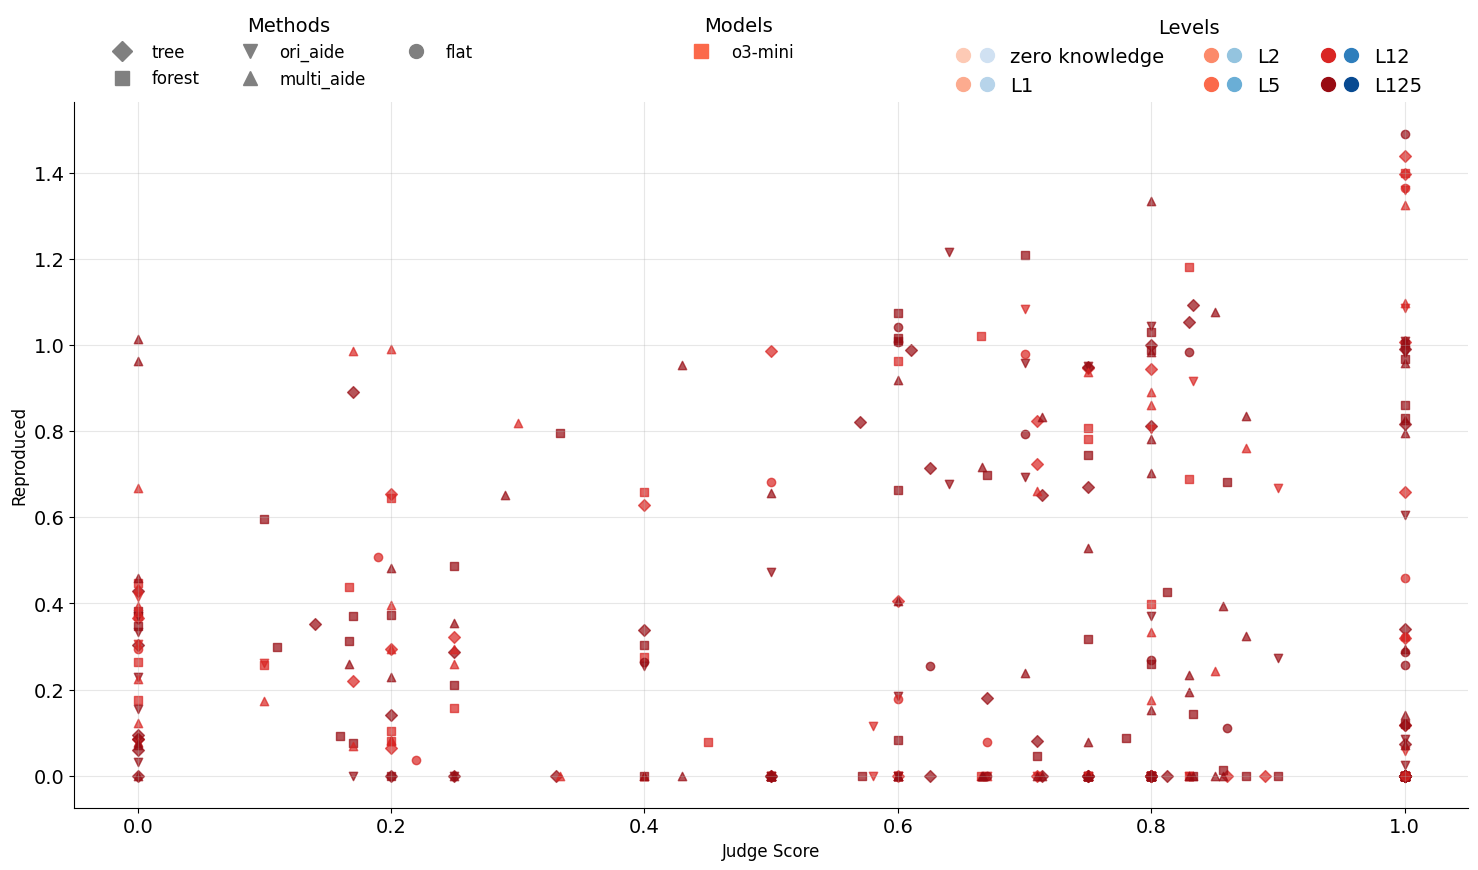

In [45]:
# Get unique methods and models
methods = new_df['method'].unique()
models = new_df['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colormaps for models
model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}

# Define level darkness scale (0 to 1)
level_darkness = {'z': 0.2, '1': 0.3, '2': 0.4, '5': 0.5, '12': 0.7, '125': 0.9}

fig, ax = plt.subplots(figsize=(15, 8))

# Plot points
for method in methods:
    for model in models:
        for level in ['z', '1', '2', '5', '12', '125']:
            mask = (new_df['method'] == method) & \
                   (new_df['model'] == model) & \
                   (new_df['levels'] == level)
            
            if mask.any():
                cmap = model_cmaps[model]
                color = cmap(level_darkness[level])
                ax.scatter(new_df[mask]['judge_score'], 
                         new_df[mask]['reproduced'],
                         marker=markers[method],
                         c=[color],
                         alpha=0.7)

ax.set_xlabel('Judge Score', fontsize=12)
ax.set_ylabel('Reproduced', fontsize=12)
# ax.set_title('L2 End vs Reproduced by Method, Model and Level', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, alpha=0.3)
# ax.invert_yaxis()

# Create legend for methods
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method, markersize=10, linestyle='None')
                 for method in methods]

# Create legend for models and levels 
model_patches = []
for model in models:
    cmap = model_cmaps[model]
    model_patches.append(
        plt.Line2D([0], [0], marker='s', color=cmap(0.5),
                   label=model, markersize=10, linestyle='None')
    )

level_patches = []
level_labels = []
for level in ['z', '1', '2', '5', '12', '125']:
    label = f'L{level}' if level != 'z' else 'zero knowledge'
    color1 = model_cmaps['o3-mini'](level_darkness[level])
    color2 = model_cmaps['deepseek-r1'](level_darkness[level])

    marker_1 = plt.Line2D([0], [0], marker='o', color=color1, markerfacecolor=color1, markersize=10, linestyle='None')
    marker_2 = plt.Line2D([0], [0], marker='o', color=color2, markerfacecolor=color2, markersize=10, linestyle='None')
    level_patches.append((marker_1, marker_2))
    level_labels.append(label)
    # level_patches.append(
    #     plt.Line2D([0], [0], marker='o', color=color,
    #                 label=label, markersize=10, linestyle='None')
    # )

# Place legends at top of figure
fig.legend(handles=method_patches, title='Methods',
           bbox_to_anchor=(0.2, 1.10), loc='upper center',
           ncol=len(method_patches)//2+1, frameon=False, fontsize=12)

fig.legend(handles=model_patches, title='Models',
           bbox_to_anchor=(0.5, 1.10), loc='upper center',
           ncol=len(model_patches), frameon=False, fontsize=12)

# fig.legend(handles=level_patches, title='Levels',
#            bbox_to_anchor=(0.8, 1.05), loc='upper center',
#            ncol=len(level_patches)//2, frameon=False, fontsize=12)
fig.legend(level_patches, level_labels, title='Levels',
           handler_map={tuple: HandlerTuple(ndivide=None)},
           loc='upper center', bbox_to_anchor=(0.8, 1.10),
           ncol=len(level_patches)//2, frameon=False)

plt.tight_layout()
plt.show()

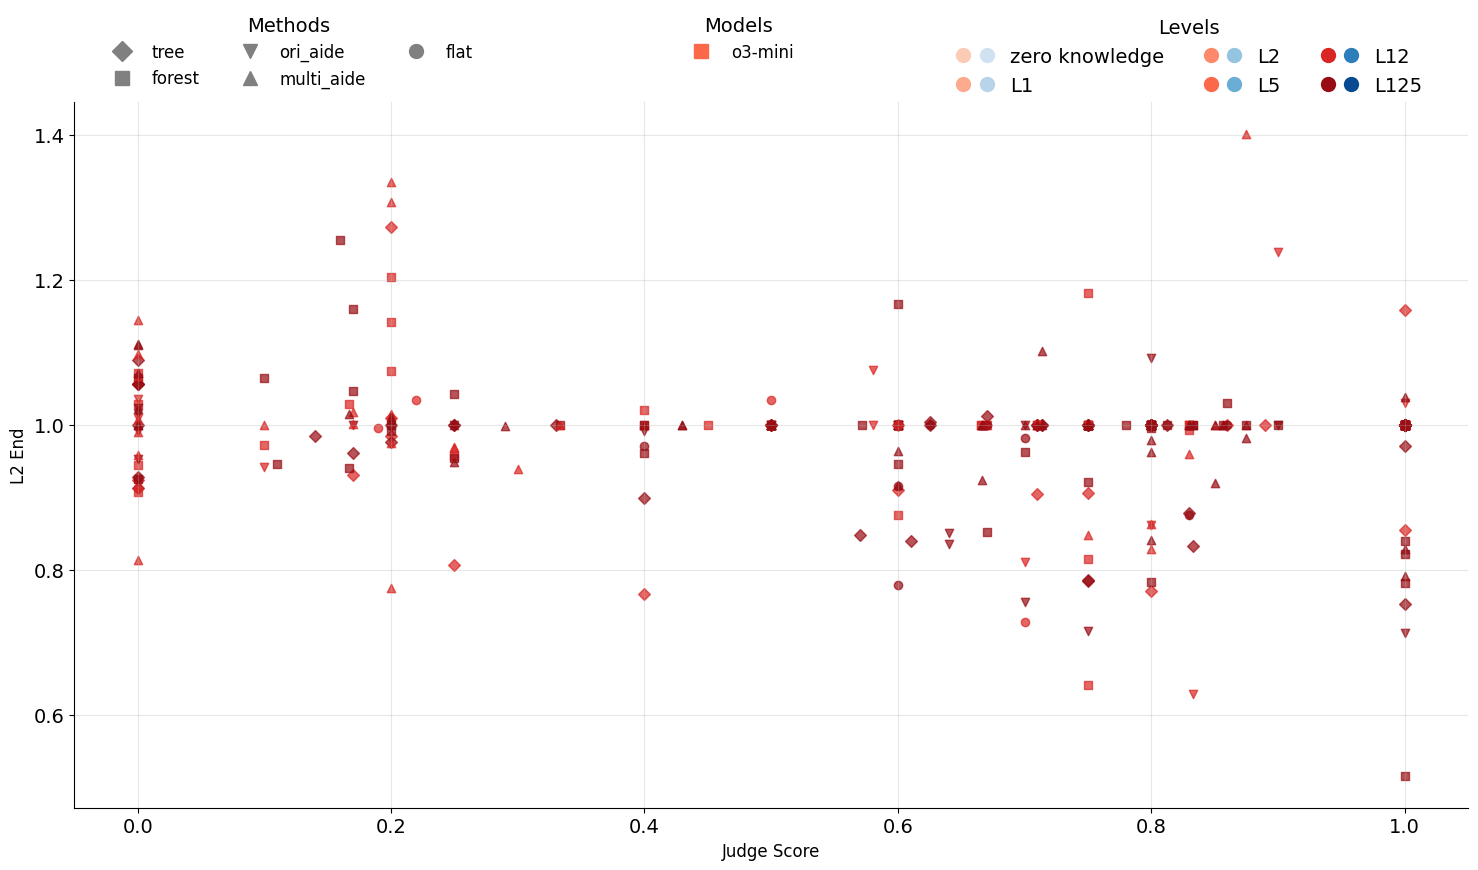

In [46]:
# Get unique methods and models
methods = new_df['method'].unique()
models = new_df['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colormaps for models
model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}

# Define level darkness scale (0 to 1)
level_darkness = {'z': 0.2, '1': 0.3, '2': 0.4, '5': 0.5, '12': 0.7, '125': 0.9}

fig, ax = plt.subplots(figsize=(15, 8))

# Plot points
for method in methods:
    for model in models:
        for level in ['z', '1', '2', '5', '12', '125']:
            mask = (new_df['method'] == method) & \
                   (new_df['model'] == model) & \
                   (new_df['levels'] == level)
            
            if mask.any():
                cmap = model_cmaps[model]
                color = cmap(level_darkness[level])
                ax.scatter(new_df[mask]['judge_score'], 
                         new_df[mask]['norm_l2_end'],
                         marker=markers[method],
                         c=[color],
                         alpha=0.7)

ax.set_xlabel('Judge Score', fontsize=12)
ax.set_ylabel('L2 End', fontsize=12)
# ax.set_title('L2 End vs Reproduced by Method, Model and Level', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, alpha=0.3)
# ax.invert_yaxis()

# Create legend for methods
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method, markersize=10, linestyle='None')
                 for method in methods]

# Create legend for models and levels 
model_patches = []
for model in models:
    cmap = model_cmaps[model]
    model_patches.append(
        plt.Line2D([0], [0], marker='s', color=cmap(0.5),
                   label=model, markersize=10, linestyle='None')
    )

level_patches = []
level_labels = []
for level in ['z', '1', '2', '5', '12', '125']:
    label = f'L{level}' if level != 'z' else 'zero knowledge'
    color1 = model_cmaps['o3-mini'](level_darkness[level])
    color2 = model_cmaps['deepseek-r1'](level_darkness[level])

    marker_1 = plt.Line2D([0], [0], marker='o', color=color1, markerfacecolor=color1, markersize=10, linestyle='None')
    marker_2 = plt.Line2D([0], [0], marker='o', color=color2, markerfacecolor=color2, markersize=10, linestyle='None')
    level_patches.append((marker_1, marker_2))
    level_labels.append(label)
    # level_patches.append(
    #     plt.Line2D([0], [0], marker='o', color=color,
    #                 label=label, markersize=10, linestyle='None')
    # )

# Place legends at top of figure
fig.legend(handles=method_patches, title='Methods',
           bbox_to_anchor=(0.2, 1.10), loc='upper center',
           ncol=len(method_patches)//2+1, frameon=False, fontsize=12)

fig.legend(handles=model_patches, title='Models',
           bbox_to_anchor=(0.5, 1.10), loc='upper center',
           ncol=len(model_patches), frameon=False, fontsize=12)

# fig.legend(handles=level_patches, title='Levels',
#            bbox_to_anchor=(0.8, 1.05), loc='upper center',
#            ncol=len(level_patches)//2, frameon=False, fontsize=12)
fig.legend(level_patches, level_labels, title='Levels',
           handler_map={tuple: HandlerTuple(ndivide=None)},
           loc='upper center', bbox_to_anchor=(0.8, 1.10),
           ncol=len(level_patches)//2, frameon=False)

plt.tight_layout()
plt.show()

In [47]:
new_df.head()

,run_id,record,method,levels,model,reproduced,norm_l2_end,judge_score,l2_end
0,record_14_20250430_102304_2174598-2158047-3,14,tree,12,o3-mini,0.000000,1.000000,1.00,26.945776
1,record_8_20250502_004536_2183027-2182665-7,8,tree,12,o3-mini,0.000000,1.000000,1.00,22.534748
2,record_11_20250430_102304_2174595-2158047-0,11,tree,12,o3-mini,0.000000,1.000000,0.80,17.181139
3,record_9_20250502_004536_2183028-2182665-8,9,tree,12,o3-mini,1.438180,1.000000,1.00,18.767290
4,record_16_20250502_121340_2186465-2185781-5,16,tree,12,o3-mini,0.322458,0.806343,0.25,23.964155


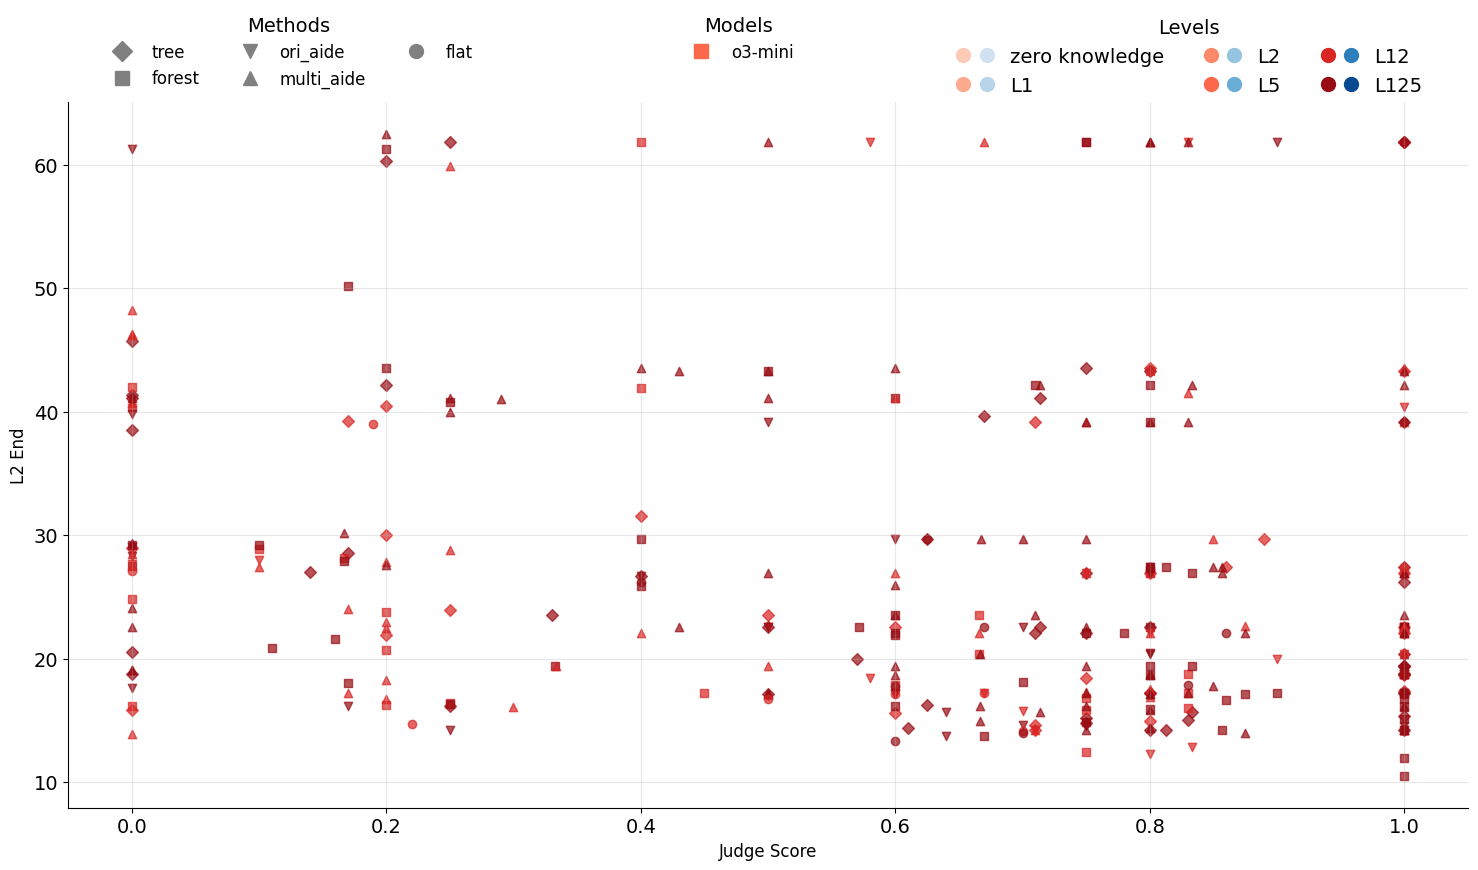

In [48]:
# Get unique methods and models
methods = new_df['method'].unique()
models = new_df['model'].unique()

# Define markers for methods
markers = {
    'flat': 'o',      # circle
    'forest': 's',    # square 
    'multi_aide': '^',  # triangle up
    'ori_aide': 'v',    # triangle down
    'tree': 'D'         # diamond
}

# Define colormaps for models
model_cmaps = {'deepseek-r1': plt.cm.Blues, 'o3-mini': plt.cm.Reds}

# Define level darkness scale (0 to 1)
level_darkness = {'z': 0.2, '1': 0.3, '2': 0.4, '5': 0.5, '12': 0.7, '125': 0.9}

fig, ax = plt.subplots(figsize=(15, 8))

# Plot points
for method in methods:
    for model in models:
        for level in ['z', '1', '2', '5', '12', '125']:
            mask = (new_df['method'] == method) & \
                   (new_df['model'] == model) & \
                   (new_df['levels'] == level)
            
            if mask.any():
                cmap = model_cmaps[model]
                color = cmap(level_darkness[level])
                ax.scatter(new_df[mask]['judge_score'], 
                         new_df[mask]['l2_end'],
                         marker=markers[method],
                         c=[color],
                         alpha=0.7)

ax.set_xlabel('Judge Score', fontsize=12)
ax.set_ylabel('L2 End', fontsize=12)
# ax.set_title('L2 End vs Reproduced by Method, Model and Level', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, alpha=0.3)
# ax.invert_yaxis()

# Create legend for methods
method_patches = [plt.Line2D([0], [0], marker=markers[method], color='gray',
                           label=method, markersize=10, linestyle='None')
                 for method in methods]

# Create legend for models and levels 
model_patches = []
for model in models:
    cmap = model_cmaps[model]
    model_patches.append(
        plt.Line2D([0], [0], marker='s', color=cmap(0.5),
                   label=model, markersize=10, linestyle='None')
    )

level_patches = []
level_labels = []
for level in ['z', '1', '2', '5', '12', '125']:
    label = f'L{level}' if level != 'z' else 'zero knowledge'
    color1 = model_cmaps['o3-mini'](level_darkness[level])
    color2 = model_cmaps['deepseek-r1'](level_darkness[level])

    marker_1 = plt.Line2D([0], [0], marker='o', color=color1, markerfacecolor=color1, markersize=10, linestyle='None')
    marker_2 = plt.Line2D([0], [0], marker='o', color=color2, markerfacecolor=color2, markersize=10, linestyle='None')
    level_patches.append((marker_1, marker_2))
    level_labels.append(label)
    # level_patches.append(
    #     plt.Line2D([0], [0], marker='o', color=color,
    #                 label=label, markersize=10, linestyle='None')
    # )

# Place legends at top of figure
fig.legend(handles=method_patches, title='Methods',
           bbox_to_anchor=(0.2, 1.10), loc='upper center',
           ncol=len(method_patches)//2+1, frameon=False, fontsize=12)

fig.legend(handles=model_patches, title='Models',
           bbox_to_anchor=(0.5, 1.10), loc='upper center',
           ncol=len(model_patches), frameon=False, fontsize=12)

# fig.legend(handles=level_patches, title='Levels',
#            bbox_to_anchor=(0.8, 1.05), loc='upper center',
#            ncol=len(level_patches)//2, frameon=False, fontsize=12)
fig.legend(level_patches, level_labels, title='Levels',
           handler_map={tuple: HandlerTuple(ndivide=None)},
           loc='upper center', bbox_to_anchor=(0.8, 1.10),
           ncol=len(level_patches)//2, frameon=False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3871442/3694067598.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.plot(x, y+idx, label=cmap, color=plt.cm.get_cmap(cmap)(0.5))


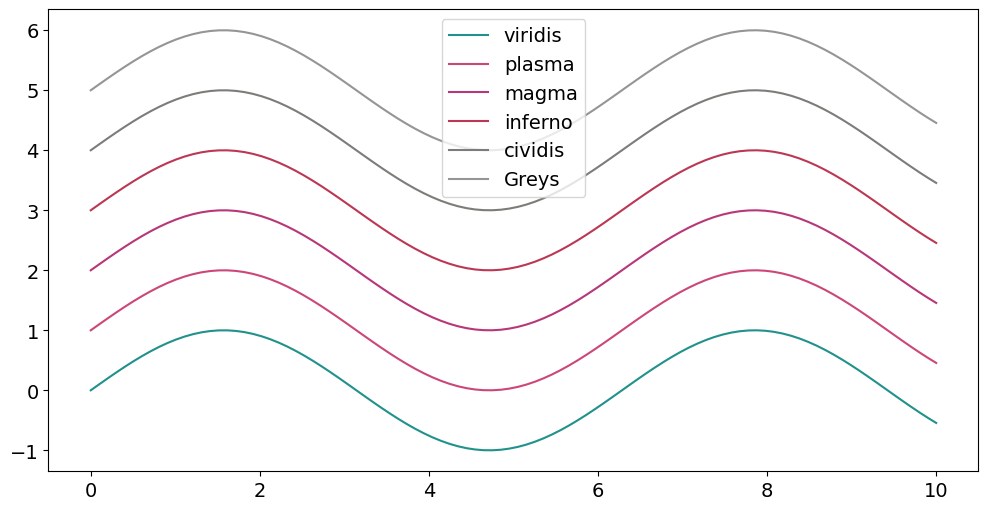

In [50]:
import numpy as np
import matplotlib.pyplot as plt
# Create some data
x = np.linspace(0, 10, 100)
y = np.sin(x)
# Create a figure and axis
fig, ax = plt.subplots()
# Plot the data using different color maps
for idx, cmap in enumerate(['viridis', 'plasma', 'magma', 'inferno', 'cividis', 'Greys']):
    ax.plot(x, y+idx, label=cmap, color=plt.cm.get_cmap(cmap)(0.5))
# Add a legend
ax.legend()
# Show the plot
plt.show()